## Introduction

In this script, the shape files of Chennai at the ward level are read in. These shape files are .kml files. Since they are difficult to work with, they are converted to .shp files using GDAL. 

We also do some basic plots and data exploration.

The data of the wards are obtained from [OpenCity](https://data.opencity.in/dataset/gcc-ward-information).

## Importing the Python libraries

In [206]:
import subprocess
from pathlib import Path

import geopandas as gpd
import pandas as pd

## Conversion to shape files

In [207]:
parent_dir = Path.cwd().parent
parent_dir

WindowsPath('c:/Ellen/personal/projects/geospatial/lst_bang_chennai/lstroad')

In [208]:
file_path_chennai = parent_dir / "data" / "raw" / "6a8a05ed-a41c-492a-aade-ff7517e1a4b1.kml"

File formats such as .kml are difficult to work with. Although Geopandas can read such files using the appropriate drivers, it is very common that columns get truncated. Hence, GDAL was used from within this Python script to conver the kml files to shape files:

In [209]:
shp_file_chennai = parent_dir / "data" / "interim" / "chennai.shp"

In [210]:
cmd = [
    "ogr2ogr",
    "-f", "ESRI Shapefile",         
    str(shp_file_chennai),          
    str(file_path_chennai)            
]

In [211]:
subprocess.run(cmd, check=True)

CompletedProcess(args=['ogr2ogr', '-f', 'ESRI Shapefile', 'c:\\Ellen\\personal\\projects\\geospatial\\lst_bang_chennai\\lstroad\\data\\interim\\chennai.shp', 'c:\\Ellen\\personal\\projects\\geospatial\\lst_bang_chennai\\lstroad\\data\\raw\\6a8a05ed-a41c-492a-aade-ff7517e1a4b1.kml'], returncode=0)

## Exploratory analysis

In [212]:
gdf_chennai = gpd.read_file(shp_file_chennai)

In [213]:
print(f'There are  {gdf_chennai.shape[0]} wards in Chennai')
print(f'There are  {gdf_chennai.shape[1]} columns in the dataset for Chennai')

There are  200 wards in Chennai
There are  14 columns in the dataset for Chennai


<Axes: >

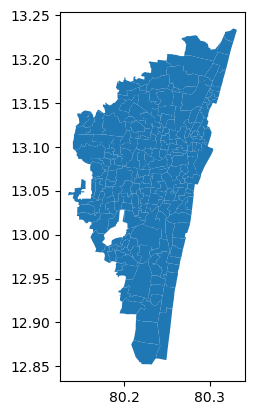

In [214]:
gdf_chennai.plot()

In [215]:
gdf_chennai.head()

,id,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,icon,id_2,geometry
0,None,168\n,None,None,None,None,None,1,0,-1,NaN,None,ID_00000\n,"POLYGON Z ((80.20975 13.02585 0, 80.20975 13.0..."
1,None,169\n,None,None,None,None,None,1,0,-1,NaN,None,ID_00001\n,"POLYGON Z ((80.23914 13.03186 0, 80.23915 13.0..."
2,None,170\n,None,None,None,None,None,1,0,-1,NaN,None,ID_00002\n,"POLYGON Z ((80.24917 13.01847 0, 80.24871 13.0..."
3,None,171\n,None,None,None,None,None,1,0,-1,NaN,None,ID_00003\n,"MULTIPOLYGON Z (((80.27906 13.02775 0, 80.2790..."
4,None,174\n,None,None,None,None,None,1,0,-1,NaN,None,ID_00004\n,"POLYGON Z ((80.27704 13.01383 0, 80.27658 13.0..."


In [216]:
gdf_chennai.columns

Index(['id', 'Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'id_2',
       'geometry'],
      dtype='object')

In [217]:
# Set options to display all rows and columns
pd.set_option("display.max_rows", None)

In [218]:
missing_values_count = gdf_chennai.isna().sum()
print("Missing values per column:")
print(missing_values_count)

Missing values per column:
id            200
Name            0
descriptio    200
timestamp     200
begin         200
end           200
altitudeMo    200
tessellate      0
extrude         0
visibility      0
drawOrder     200
icon          200
id_2            0
geometry        0
dtype: int64


In [219]:
gdf_chennai['Name'].nunique()

200

## Basic data clean up and the creation of the zones

In [220]:
cols_to_keep = [
    "Name",
    "geometry",
]

gdf_chennai = gdf_chennai[cols_to_keep]
gdf_chennai.head()

,Name,geometry
0,168\n,"POLYGON Z ((80.20975 13.02585 0, 80.20975 13.0..."
1,169\n,"POLYGON Z ((80.23914 13.03186 0, 80.23915 13.0..."
2,170\n,"POLYGON Z ((80.24917 13.01847 0, 80.24871 13.0..."
3,171\n,"MULTIPOLYGON Z (((80.27906 13.02775 0, 80.2790..."
4,174\n,"POLYGON Z ((80.27704 13.01383 0, 80.27658 13.0..."


Before proceeding, let us remove the "\n" from the "Name" variable:

In [221]:
gdf_chennai = gdf_chennai.copy()
gdf_chennai["Name"] = gdf_chennai['Name'].str.split("\n").str[0]
## gdf_chennai


In Chennai, the city is split up in 15 zones with each several wards. More information can be found on the website of the [Greater Chennai Corporation](https://chennaicorporation.gov.in/gcc/delimited_ward/). 

The [OpenCity data](https://data.opencity.in/dataset/gcc-ward-information) have a map with the 15 different zones in Chennai. After some initial trails, it was a bit challenging to do the spatial join so it was much more efficient to just code the different zones based on the Greater Chennai Corporation link:

In [222]:
gdf_chennai.dtypes

Name          object
geometry    geometry
dtype: object

In [225]:
# Convert the wards (that are objects) to numeric
gdf_chennai['Name'] = pd.to_numeric(gdf_chennai['Name'], errors='coerce').astype('Int64')

zones = [
    (1, 14, 1, "Thiruvottyur"),
    (15, 22, 2, "Manali"),
    (23, 33, 3, "Madhavaram"),
    (34, 48, 4, "Tondiarpet"),
    (49, 63, 5, "Royapuram"),
    (64, 78, 6, "Thiru-Vi-Ka. Nagar"),
    (79, 93, 7, "Ambattur"),
    (94, 108, 8, "Anna Nagar"),
    (109, 126, 9, "Teynampet"),
    (127, 142, 10, "Kodambakkam"),
    (143, 155, 11, "Valasaravakkam"),
    (156, 167, 12, "Alandur"),
    (168, 180, 13, "Adyar"),
    (181, 191, 14, "Perungudi"),
    (192, 200, 15, "Sholinganallur")
]

def make_zone(name):
    for start, end, zone_id, zone_name in zones:
        if start <= name <= end:
            return pd.Series([zone_id, zone_name])
    return pd.Series([pd.NA, pd.NA])

gdf_chennai[['zone_id', 'zone_name']] = gdf_chennai['Name'].apply(make_zone)

## To check
## gdf_chennai.head(20)


Next, we check if the geometries are valid. The reason for doing so is that they can cause trouble later on in the analysis. 

In [226]:
valid = gdf_chennai.is_valid
valid.value_counts()

True     191
False      9
Name: count, dtype: int64

Initially, we tried to make the polygons valid in Geopandas itself and then ran them through a validity check in QGIS. Running the check in QGIS revealed that still one polygon was invalid. We also ran Mapshaper to check the validity on top of this.

Hence, the validity and topology checking was done in QGIS and Mapshaper following the YouTube tutorial of Ujaval Gandhi.

Before fixing the polygons, let's save to a shape file:

In [227]:
shp_file_chennai_trimmed = parent_dir / "data" / "interim"/ "chennai_trimmed.shp"

In [228]:
gdf_chennai.to_file(shp_file_chennai_trimmed)

However, we still see a hole and we want this filled up:

In [71]:
from shapely.geometry import Polygon, MultiPolygon

def close_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)

    elif geom.geom_type == "MultiPolygon":
        return MultiPolygon(
            [Polygon(p.exterior) for p in geom.geoms]
        )

    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")



In [79]:
# I want to keep the original dissolved file and first create a copy
dissolved_chennai_copy = dissolved_chennai.copy()
dissolved_chennai_copy["geometry"] = dissolved_chennai_copy.geometry.apply(close_holes)

<Axes: >

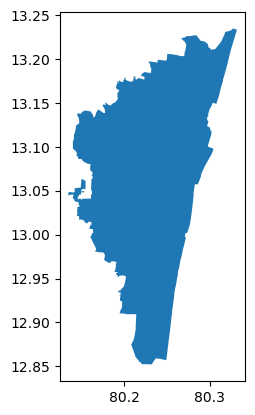

In [80]:
dissolved_chennai_copy.plot()

In [89]:
# Which geometries are invalid and why
# Extracts the polygons which are not valid
invalid = gdf_chennai[~gdf_chennai.geometry.is_valid]
invalid.head()

,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,icon,id_2,geometry,validity_reason
24,183\n,None,None,None,None,None,1,0,-1,None,None,ID_00024\n,"POLYGON Z ((80.25220 12.96771 0.00000, 80.2520...",Ring Self-intersection
31,115\n,None,None,None,None,None,1,0,-1,None,None,ID_00031\n,"POLYGON Z ((80.27412 13.05887 0.00000, 80.2740...",Ring Self-intersection
96,69\n,None,None,None,None,None,1,0,-1,None,None,ID_00096\n,"POLYGON Z ((80.23155 13.11604 0.00000, 80.2317...",Self-intersection
135,129\n,None,None,None,None,None,1,0,-1,None,None,ID_00135\n,"POLYGON Z ((80.19704 13.05468 0.00000, 80.1970...",Ring Self-intersection
149,42\n,None,None,None,None,None,1,0,-1,None,None,ID_00149\n,"POLYGON Z ((80.27764 13.11399 0.00000, 80.2776...",Ring Self-intersection


## Appendix

The reason for the invalid geometries:

In [233]:
invalid = gdf_chennai[~gdf_chennai.is_valid]

print(len(invalid))

invalid

9


,Name,geometry,zone_id,zone_name,validity_reason
24,183,"POLYGON Z ((80.2522 12.96771 0, 80.25208 12.96...",14,Perungudi,Ring Self-intersection
31,115,"POLYGON Z ((80.27412 13.05887 0, 80.27409 13.0...",9,Teynampet,Ring Self-intersection
96,69,"POLYGON Z ((80.23155 13.11604 0, 80.23175 13.1...",6,Thiru-Vi-Ka. Nagar,Self-intersection
135,129,"POLYGON Z ((80.19704 13.05468 0, 80.19705 13.0...",10,Kodambakkam,Ring Self-intersection
149,42,"POLYGON Z ((80.27764 13.11399 0, 80.27764 13.1...",4,Tondiarpet,Ring Self-intersection
188,65,"POLYGON Z ((80.21838 13.11782 0, 80.21838 13.1...",6,Thiru-Vi-Ka. Nagar,Ring Self-intersection
190,91,"POLYGON Z ((80.17417 13.07581 0, 80.17422 13.0...",7,Ambattur,Ring Self-intersection
192,39,"POLYGON Z ((80.28871 13.13967 0, 80.28853 13.1...",4,Tondiarpet,Ring Self-intersection
196,161,"POLYGON Z ((80.20593 12.99985 0, 80.20615 12.9...",12,Alandur,Ring Self-intersection


In [234]:
invalid = invalid.copy()
invalid['reason_invalid'] = invalid.geometry.is_valid_reason()
invalid

,Name,geometry,zone_id,zone_name,validity_reason,reason_invalid
24,183,"POLYGON Z ((80.2522 12.96771 0, 80.25208 12.96...",14,Perungudi,Ring Self-intersection,Ring Self-intersection[80.2522005200892 12.967...
31,115,"POLYGON Z ((80.27412 13.05887 0, 80.27409 13.0...",9,Teynampet,Ring Self-intersection,Ring Self-intersection[80.2736156910137 13.052...
96,69,"POLYGON Z ((80.23155 13.11604 0, 80.23175 13.1...",6,Thiru-Vi-Ka. Nagar,Self-intersection,Self-intersection[80.2187977932016 13.11111307...
135,129,"POLYGON Z ((80.19704 13.05468 0, 80.19705 13.0...",10,Kodambakkam,Ring Self-intersection,Ring Self-intersection[80.1970510234224 13.054...
149,42,"POLYGON Z ((80.27764 13.11399 0, 80.27764 13.1...",4,Tondiarpet,Ring Self-intersection,Ring Self-intersection[80.2865138896145 13.121...
188,65,"POLYGON Z ((80.21838 13.11782 0, 80.21838 13.1...",6,Thiru-Vi-Ka. Nagar,Ring Self-intersection,Ring Self-intersection[80.21414488455 13.11692...
190,91,"POLYGON Z ((80.17417 13.07581 0, 80.17422 13.0...",7,Ambattur,Ring Self-intersection,Ring Self-intersection[80.1772084413218 13.078...
192,39,"POLYGON Z ((80.28871 13.13967 0, 80.28853 13.1...",4,Tondiarpet,Ring Self-intersection,Ring Self-intersection[80.2926717275228 13.133...
196,161,"POLYGON Z ((80.20593 12.99985 0, 80.20615 12.9...",12,Alandur,Ring Self-intersection,Ring Self-intersection[80.2070213512584 12.999...


## References

https://chennaicorporation.gov.in/gcc/delimited_ward/

https://pythongis.org/part2/chapter-06/nb/02-geometric-operations.html

https://chennaicorporation.gov.in/gcc/delimited_ward/